In [1]:
import pandas as pd

In [8]:
df = pd.read_csv(r'C:\Users\Monishaa Sri .P\Downloads\sales_data.csv')

it displays the first rows

In [62]:
print(df.head())

   Order_ID Customer_Name   Age  Gender     Product  Quantity  Price  \
0      1001         Meena  26.0  female  Headphones         2  22333   
1      1002         Arjun  46.0  female       Phone         2  38650   
2      1003         Kiran  56.0  female      Laptop         3  33674   
3      1004         Arjun  52.0  female       Phone         1  34854   
4      1005         Arjun  46.0    male      Tablet         1  45271   

  Order_Date       City  Total_Amount  
0 2023-01-01  Hyderabad         44666  
1 2023-01-02      Delhi         77300  
2 2023-01-03    Chennai        101022  
3 2023-01-04  Bangalore         34854  
4 2023-01-05     Mumbai         45271  


it prints the rows and columns

In [10]:
print(df.shape)

(205, 9)


In [ ]:
it prints the whole info

In [12]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       200 non-null    float64
 1   Customer_Name  205 non-null    str    
 2   Age            195 non-null    float64
 3   Gender         195 non-null    str    
 4   Product        205 non-null    str    
 5   Quantity       205 non-null    int64  
 6   Price          205 non-null    int64  
 7   Order_Date     205 non-null    str    
 8   City           205 non-null    str    
dtypes: float64(2), int64(2), str(5)
memory usage: 14.5 KB
None


it sums the null value

In [11]:
print(df.isnull().sum)

<bound method DataFrame.sum of      Order_ID  Customer_Name    Age  Gender  Product  Quantity  Price  \
0       False          False  False   False    False     False  False   
1       False          False  False   False    False     False  False   
2       False          False  False   False    False     False  False   
3       False          False  False   False    False     False  False   
4       False          False  False   False    False     False  False   
..        ...            ...    ...     ...      ...       ...    ...   
200     False          False  False   False    False     False  False   
201     False          False  False   False    False     False  False   
202     False          False  False   False    False     False  False   
203     False          False  False   False    False     False  False   
204     False          False  False   False    False     False  False   

     Order_Date   City  
0         False  False  
1         False  False  
2         False  

handle missing value

In [14]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [15]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [16]:
df = df.dropna(subset=['Order_ID'])

Remove duplicates

In [17]:
df = df.drop_duplicates()

fix data types

In [19]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

clean text data

In [21]:
df['Customer_Name'] = df['Customer_Name'].str.strip()
df['City'] = df['City'].str.strip()

In [38]:
df['Gender'] = df['Gender'].str.strip().str.lower()

In [40]:
df['Gender'] = df['Gender'].replace({'m':'male', 'f':'female'})

In [66]:
print(df.to_string())

     Order_ID Customer_Name   Age  Gender     Product  Quantity  Price Order_Date       City  Total_Amount
0        1001         Meena  26.0  female  Headphones         2  22333 2023-01-01  Hyderabad         44666
1        1002         Arjun  46.0  female       Phone         2  38650 2023-01-02      Delhi         77300
2        1003         Kiran  56.0  female      Laptop         3  33674 2023-01-03    Chennai        101022
3        1004         Arjun  52.0  female       Phone         1  34854 2023-01-04  Bangalore         34854
4        1005         Arjun  46.0    male      Tablet         1  45271 2023-01-05     Mumbai         45271
5        1006          Ravi  33.0    male       Phone         2   7152 2023-01-06     Mumbai         14304
6        1007         Kiran  33.0    male       Phone         1  37518 2023-01-07  Hyderabad         37518
9        1010         Arjun  50.0  female      Laptop         3  24289 2023-01-10    Chennai         72867
10       1011         Meena  53.0    

In [37]:
df = df.drop(columns=['gender'])

Handle invalid values

In [42]:
df = df[df['Age']>0]
df = df[df['Price']>0]

calculation

In [44]:
df['Total_Amount'] =df['Quantity'] * df['Price']



IQR Method

In [47]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Price'] >= Q1 - 1.5 * IQR) & (df['Price'] <= Q3 + 1.5 * IQR)]

Final check

In [49]:
print(df.isnull().sum())

Order_ID         0
Customer_Name    0
Age              0
Gender           0
Product          0
Quantity         0
Price            0
Order_Date       0
City             0
Total_Amount     0
dtype: int64


In [50]:
print(df.duplicated().sum())

0


In [51]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 173 entries, 0 to 199
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       173 non-null    float64       
 1   Customer_Name  173 non-null    str           
 2   Age            173 non-null    float64       
 3   Gender         173 non-null    str           
 4   Product        173 non-null    str           
 5   Quantity       173 non-null    int64         
 6   Price          173 non-null    int64         
 7   Order_Date     173 non-null    datetime64[us]
 8   City           173 non-null    str           
 9   Total_Amount   173 non-null    int64         
dtypes: datetime64[us](1), float64(2), int64(3), str(4)
memory usage: 14.9 KB
None


In [54]:
df['Order_ID'].head()
df.dtypes

Order_ID                float64
Customer_Name               str
Age                     float64
Gender                      str
Product                     str
Quantity                  int64
Price                     int64
Order_Date       datetime64[us]
City                        str
Total_Amount              int64
dtype: object

In [61]:
df['Order_ID'] = df['Order_ID'].astype(int)

Saved file

In [58]:
df.to_csv("cleaned_sales_data.csv", index=False)

In [59]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'cleaned_sales_data.csv', 'Untitled.ipynb']


In [60]:
new_df = pd.read_csv("cleaned_sales_data.csv")
new_df.head()

,Order_ID,Customer_Name,Age,Gender,Product,Quantity,Price,Order_Date,City,Total_Amount
0,1001,Meena,26.0,female,Headphones,2,22333,2023-01-01,Hyderabad,44666
1,1002,Arjun,46.0,female,Phone,2,38650,2023-01-02,Delhi,77300
2,1003,Kiran,56.0,female,Laptop,3,33674,2023-01-03,Chennai,101022
3,1004,Arjun,52.0,female,Phone,1,34854,2023-01-04,Bangalore,34854
4,1005,Arjun,46.0,male,Tablet,1,45271,2023-01-05,Mumbai,45271


Bonus task summary of report

describe does statistical calculation

In [63]:
print(df.describe())

          Order_ID         Age    Quantity         Price  \
count   173.000000  173.000000  173.000000    173.000000   
mean   1102.884393   34.554913    2.485549  22797.994220   
min    1001.000000    1.000000    1.000000     62.000000   
25%    1055.000000   18.000000    2.000000   9789.000000   
50%    1103.000000   33.000000    2.000000  20852.000000   
75%    1153.000000   50.000000    3.000000  35976.000000   
max    1200.000000   69.000000    4.000000  49612.000000   
std      56.860891   18.849269    1.054376  14525.773367   

                       Order_Date   Total_Amount  
count                         173     173.000000  
mean   2023-04-12 21:13:31.560693   54953.526012  
min           2023-01-01 00:00:00      62.000000  
25%           2023-02-24 00:00:00   20604.000000  
50%           2023-04-13 00:00:00   40427.000000  
75%           2023-06-02 00:00:00   77300.000000  
max           2023-07-19 00:00:00  182056.000000  
std                           NaN   44510.575858  


it is used to sort the output better for marks

In [64]:
city_sales = df.groupby('City')['Total_Amount'].sum().reset_index()
print(city_sales)

        City  Total_Amount
0  Bangalore       1991159
1    Chennai       2030769
2      Delhi       2328227
3  Hyderabad       1662172
4     Mumbai       1494633


In [67]:
city_sales = city_sales.sort_values(by='Total_Amount', ascending=False)
print(city_sales)

        City  Total_Amount
2      Delhi       2328227
1    Chennai       2030769
0  Bangalore       1991159
3  Hyderabad       1662172
4     Mumbai       1494633


Sales trend visualization

In [69]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -------------- ------------------------- 2.9/8.1 MB 14.0 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 16.1 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 15.3 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 14.8 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   -------------------- ------------------- 3.7/7.1 MB 18.1 MB/s eta 0:00:01
   ----------------------------------- ---- 6.3/7.1 MB 15.4 MB/s eta 0:00:01
   ---------------------------------------- 7.1/7.1 MB 14.1 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------

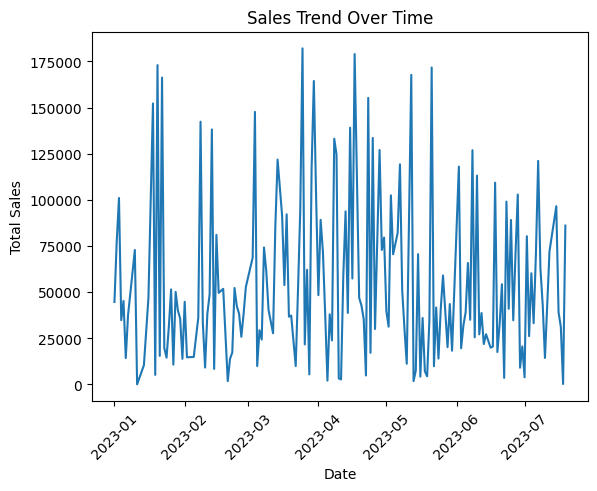

In [70]:
import matplotlib.pyplot as plt
sales_trend = df.groupby('Order_Date')['Total_Amount'].sum().reset_index()
plt.figure()
plt.plot(sales_trend['Order_Date'], sales_trend['Total_Amount'])
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Sales Trend Over Time")
plt.xticks(rotation=45)
plt.show()

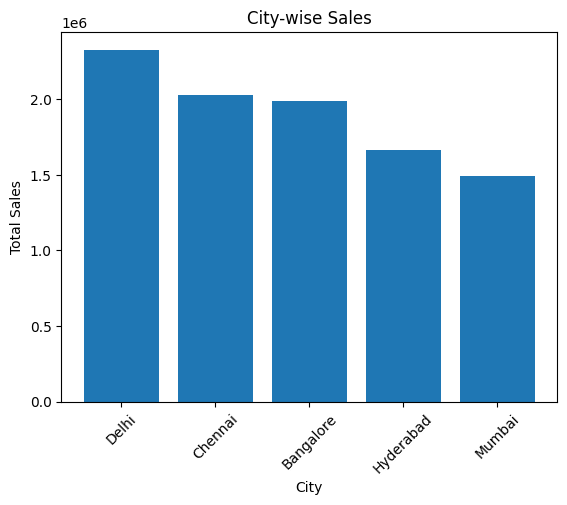

In [71]:
plt.figure()
plt.bar(city_sales['City'], city_sales['Total_Amount'])
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.title("City-wise Sales")
plt.xticks(rotation=45)
plt.show()

In [72]:
plt.savefig("city_sales.png")

<Figure size 640x480 with 0 Axes>